# 03 — Reconstruct, build and audit a three-box model

**Learning goals:** reconstruct a scientific flux diagram; translate it through Excel records into native ESBMTK objects; explain contrasting organic/carbonate effects on pCO2; distinguish graph, budget and restart checks.

**Provisional time: 55 minutes.** Diagram, paired flux equations and Excel reconciliation (15), four native mappings (20), boundary budget and checks (15), explanation (5).

Follow **reconstruct → reconcile → map → run → check → explain**. Your diagram and paired flux equations are the specification for your code and for 04. Repeated loops, chemistry/sediment wiring, integration and plotting are supplied.
[Teaching goals and instructor timing notes](../../TEACHING_GOALS.md).

**Reading key:** <mark style="background-color: #fff0b3; color: #513d00; padding: 0.05em 0.2em; border-radius: 3px;"><strong>Key term</strong></mark> = concept to notice. Blue **Question** panels identify student work; purple **Instructor answer** panels appear only in the instructor sheet.
Code labels distinguish **Choose and explain**, **Understand and run**, and **Supplied implementation**.
This practical is ungraded. Keep your explanations here; no separate submission is required.
The [coding cheatsheet](../../ref/modelling_cheatsheet.md) is optional lookup support; essential syntax is explained locally.

## A1. What changes from 02?

This is a Boudreau-like benchmark with a different specification. Do not carry over 02's fitted k, ratio-derived geometry or total carbon inventory.

| Feature | 02 | 03/04 |
| --- | --- | --- |
| Geometry and conditions | Two layers, uniform T/S/P | Low-/high-latitude surface and deep boxes; box-specific conditions |
| Organic export | $kDIC_s(t)$ | Fixed POC export |
| Carbonate processes | Absent | PIC export, dissolution and net burial |
| Active atm–ocn boundary | Closed except the pulse | Weathering and net burial; forcing added in 04 |
| Reference state | Calibrated constraints | Archived benchmark restart |

POC and PIC mean **particulate organic and inorganic carbon**. Here POC export includes full deep remineralization: conversion back to dissolved carbon. There is no explicit particle or nutrient inventory. The **rain ratio** is PIC/POC carbon export; the workbook prescribes this ratio and POC, then the loader derives PIC.

Read [ESBMTK section 3 and Figure 3](../../ref/ESBMTK.pdf#page=8) (printed p. 1162; [online version](https://gmd.copernicus.org/articles/18/1155/2025/#section3)). Use these corrections:

- The organic-export label in the prose should be **F5**, not F3; F3 denotes circulation.
- The benchmark uses **F6/F5 = PIC/POC = 0.3**, not the inverted ratio in the prose.
- Weathering supplies **dissolved inorganic carbon** here, not organic carbon.

Figure 3 is an incomplete specification: its arrows omit equations, stoichiometry and an explicit dissolution return. Reconstruct those properties using the following assumptions and workbook inputs.

### Process rules for your equations

- Water carries both dissolved tracers at the **source concentration**. Draw the circulation loop L_b → H_b → D_b → L_b and both H_b ↔ D_b mixing directions.
- Each surface exchanges CO2 with the same finite atm. Use invasion and outgassing as in 01/02.
- Only L_b exports POC/PIC. The table supplies the benchmark's biological, carbonate and weathering assumptions beside their rows.
- Draw a distinct carbonate/sediment **process module** with an explicit dissolution return. The **snowline** is the deepest boundary of existing reactive carbonate sediment. It records sediment history; the module has no explicit sediment-carbon inventory. Detailed sediment equations remain [optional](../../ref/sediment_reference.md).


In [1]:
# Supplied implementation: run this support code as provided.
from pathlib import Path
import sys
import pandas as pd
import numpy as np

ROOT = next(p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
            if (p / 'teaching_config.py').is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from esbmtk import (
    Q_, ConnectionProperties, GasReservoir, Model, Species2Species,
    add_carbonate_system_1, add_carbonate_system_2,
    create_bulk_connections, initialize_reservoirs,
)
from model import postprocess_carbonate_horizons, run_model, standard_diagnostics
from presets import load_boudreau_parameters
from reservoir_inputs import reservoir_inventory_rows
from model_inputs import read_model_tables

WORKBOOK = ROOT / 'data' / 'Boudreau_2010' / 'model_definition.xlsx'
P = load_boudreau_parameters(WORKBOOK)
input_tables = read_model_tables(WORKBOOK)
STATE = ROOT / 'data' / 'Boudreau_2010' / 'steady_state'
from teaching_specification import BASELINE_PARAMETERS, workbook_connections
from teaching_audits import audit_benchmark_graph, audit_complete_model, audit_restart_drift

### A2. Inspect the numerical inputs

The workbook owns areas, volumes, box-specific T/S/P and initial states. The atmosphere has its own mole-fraction and total-air units. **Initial concentrations are replaced by the archived restart later.** Geometry and rates are retained.

For now inspect only reservoir and baseline parameter tables. Connection rows come after your reconstruction. Optional feedback settings are omitted from this view. Excel editing is not required.

In [2]:
# Understand and run: read these supplied inputs before drawing.
display(pd.DataFrame(input_tables['OceanReservoirs']).set_index('Box ID'))
display(pd.DataFrame(input_tables['Atmosphere']).set_index('Box ID'))
baseline_parameters = pd.DataFrame(input_tables['ProcessParameters']).set_index('Parameter')
display(baseline_parameters.loc[list(BASELINE_PARAMETERS)])

,Description,Area (m2),Volume (m3),Temperature (degC),Salinity,Pressure (bar),Initial DIC (umol/kg),Initial TA (umol/kg)
Box ID,,,,,,,,
H_b,High-latitude surface,50000000000000,17600000000000000,2.0,35,17.6,2153,2345
L_b,Low-latitude surface,285000000000000,28500000000000000,21.5,35,5.0,1952,2288
D_b,Deep ocean,336000000000000,1290000000000000000,2.0,35,240.0,2291,2399


,Total air (mol),Initial CO2 (ppm),Role
Box ID,,,
CO2_At,177860000000000000000,280,Prognostic CO2


,Value,Unit,Role,Description
Parameter,,,,
thc,25.0,Sverdrup,Prescribed transport,Water transport on every leg of the overturnin...
mixing,30.0,Sverdrup,Prescribed transport,Equal exchange in both directions between high...
poc_export,200.0,Tmol/yr,Prescribed export,POC carbon export from low-latitude surface to...
rain_ratio,0.3,1,Prescribed ratio,PIC/POC carbon-export ratio at unit pump stren...
weathering_dic,12.0,Tmol/yr,Prescribed boundary flux,Carbonate weathering: one DIC and two TA equiv...
alpha,0.6,1,Benchmark coefficient,Carbonate compensation coefficient
z0,-200.0,m,Benchmark elevation,Carbonate compensation reference elevation
piston_velocity,4.8,m/d,Prescribed exchange rate,Common gas transfer velocity at both surface b...
opt_k_carbonic,13.0,1,Chemistry choice,PyCO2SYS carbonic-acid constant option


## A3. Exercise 03.1: write the paired fluxes and label the diagram

### Step 1 — Write the paired fluxes

<div style="background-color: #edf5ff; color: #173b61; border-left: 4px solid #3977b8; padding: 12px 16px; margin: 16px 0; border-radius: 4px;">

**Question — equations on arrows**

Complete both flux columns, including zero effects. Use one family expression for repeated water/gas arrows. Keep only actual state dependencies; mark each row **fixed**, **state-dependent**, or **residual** beside its process ID.

</div>

Use the notation and supplied hints below. Fill the table here or in the [student Excel worksheet](../../outputs/03_04_flux_specification/student.xlsx), whose amber fields are answer spaces. Write symbolic equations, not Excel calculation formulas.


#### Notation

Use <mark style="background-color: #fff0b3; color: #513d00; padding: 0.05em 0.2em; border-radius: 3px;"><strong>amount fluxes</strong></mark> $J_a^{DIC}(t)$ [mol C/yr] and $J_a^{TA}(t)$ [equivalents/yr] for process $a$.
Positive follows the arrow: subtract at its source and add at its destination.
The DIC superscript tracks carbon removed from/returned to dissolved inventories, even when carried as CO2 or particles. Gas exchange and net burial can be negative.

<table style="width:100%;table-layout:fixed"><thead><tr><th style="width:30%;text-align:left">Symbol</th><th style="width:70%;text-align:left">Meaning / units</th></tr></thead><tbody><tr><td style="text-align:left;vertical-align:top">$DIC_i(t),TA_i(t)$</td><td style="text-align:left;vertical-align:top">Evolving box concentrations [mol C/kg, eq/kg]; $i=L_b,H_b,D_b$</td></tr><tr><td style="text-align:left;vertical-align:top">$Q_{ij}$</td><td style="text-align:left;vertical-align:top">Water volume transport from $i$ to $j$ [m³/yr]; $\rho_iQ_{ij}$ converts it to mass transport [kg/yr]</td></tr><tr><td style="text-align:left;vertical-align:top">$\rho_i,m_i$</td><td style="text-align:left;vertical-align:top">ESBMTK density $\rho(T_i,S_i,p_i)$ [kg/m³] and fixed box water mass $m_i=\rho_iV_i$ [kg]</td></tr><tr><td style="text-align:left;vertical-align:top">$P_0,r,W_0$</td><td style="text-align:left;vertical-align:top">Prescribed POC carbon export [mol C/yr], PIC/POC rain ratio [dimensionless], weathering carbon input [mol C/yr]</td></tr><tr><td style="text-align:left;vertical-align:top">$E(t),D(t),B_{net}(t)$</td><td style="text-align:left;vertical-align:top">Carbonate export, dissolution and signed net burial [mol C/yr]</td></tr></tbody></table>

Here $p_i$ is water pressure; $pCO_{2,atm}$ is atmospheric CO2 partial pressure.
**Transport convention:** use physical $\rho Q$ for these equations; B2 explains the historical unit conversion retained in the benchmark code.


#### Supplied hints and flux table

For gas exchange, chemistry supplies aqueous CO2:

$$c_i(t)=\mathcal C(DIC_i(t),TA_i(t);T_i,S_i,p_i).$$

Use area $A_i$ [m²] and velocity $v_i$ [m/yr]. Invasion uses $K_{0,i}pCO_{2,atm}(t)$; outgassing uses $c_i(t)$, both in mol/m³. Local solubility $K_{0,i}$ converts partial pressure to concentration. Form the two directional transfers before taking their difference. Supplied chemistry handles mol/kg and dry-air mole-fraction conversions.

For dissolution, **use this supplied dependency function**:

$$D(t)=\mathcal D\!\left(E(t),DIC_d(t),TA_d(t),z_{snow}(t);T_d,S_d,p_d,\alpha,z_0\right).$$

Here $d$ means D_b, $z_{snow}$ is the snowline, and $\alpha,z_0$ are workbook sediment parameters. This states the dependencies; the sediment equations and their code are supplied.

In this model, POC export changes DIC but leaves TA unchanged (the **DIC-only closure** in the table).

| Process | Arrow | $J^{DIC}(t)$ [mol C/yr] | $J^{TA}(t)$ [eq/yr] | Inputs / hint |
| --- | --- | --- | --- | --- |
| Q_* | Water: i -> j | Your expression | Your expression | Q_ij: water volume transport (m3/yr), from thc / mixing. Use source density and concentration. |
| G_L / G_H | Gas: atm -> surface i (signed) | Your expression | Your expression | piston_velocity, area; K0_i and c_i from local chemistry. Invasion minus outgassing. |
| POC | Organic export: your arrow | Your expression | Your expression | P_0 = poc_export; fixed, fully remineralized at depth; DIC-only closure. |
| PIC | Carbonate export: L_b -> module | Your expression | Your expression | r = rain_ratio (PIC/POC); CaCO3 formation removes 1 carbon and 2 TA equivalents. |
| W | Weathering: outside -> L_b | Your expression | Your expression | W_0 = weathering_dic; the model adds 2 TA equivalents per mole of DIC. |
| D | Dissolution: module -> D_b | $D(t)$ (supplied) | Your expression | D = sediment_response(E, DIC_d, TA_d, z_snow; T_d, S_d, p_d, alpha, z0). Reverse CaCO3 formation. |
| B_net | Net burial: module -> outside (signed) | Your expression | Your expression | Compare carbonate rain and dissolution, including old sediment; residual, not an extra drain. |

<details>
<summary>Assumption notes: biology, weathering and fixed rates</summary>

The POC assumption omits nutrient/redox effects on TA. Nitrate uptake can increase TA and ammonium uptake can decrease it; a richer model needs the associated nutrient bookkeeping.

The model adds **1 mole of DIC and 2 equivalents of TA** through weathering. Real riverine input need not have exactly this 1:2 ratio.

Constant parameters do not imply constant fluxes: 02's export depended on $DIC_s(t)$ even with fixed $k$. Here both exports are fixed, but gas exchange and dissolution still respond to state. Additional pump feedbacks remain optional.

</details>


### Step 2 — Label the diagram

<div style="background-color: #edf5ff; color: #173b61; border-left: 4px solid #3977b8; padding: 12px 16px; margin: 16px 0; border-radius: 4px;">

**Question — label the diagram**

Draw and label the arrows with these expressions. Add states and the active atm–ocn boundary; distinguish chemistry diagnostics and sediment memory. Check water balance at H_b.

</div>

Label water arrows with $Q$: circulation $Q_{LH},Q_{HD},Q_{DL}$ and mixing $Q_{mix,down},Q_{mix,up}$. The paired $J$ equations describe the tracers they carry. F1–F8 remain paper aliases. Net burial is the signed amount left after dissolution, not an additional drain from deep water.

![Box outlines for reconstruction](../../ref/figures/03_04_boudreau_student.png)


### Step 3 — Check one internal transfer

For any internal dissolved transfer of $X=DIC$ or $TA$, **flux and concentration tendency differ**:

$$\left.\frac{dX_i}{dt}\right|_{i\to j}=-\frac{J^X_{ij}(t)}{m_i},\qquad
\left.\frac{dX_j}{dt}\right|_{i\to j}=+\frac{J^X_{ij}(t)}{m_j}.$$

<div style="background-color: #edf5ff; color: #173b61; border-left: 4px solid #3977b8; padding: 12px 16px; margin: 16px 0; border-radius: 4px;">

**Question — check inventory cancellation**

For one internal arrow, use the supplied tendency rule above to show equal-and-opposite inventory changes. Do not rewrite the effects in prose.

</div>


<!-- BEGIN SOLUTION -->
<div style="background-color: #f3eefb; color: #38224f; border-left: 4px solid #7952a8; padding: 12px 16px; margin: 16px 0; border-radius: 4px;">

**Instructor answer**

The completed equations are tabulated below. POC, PIC and weathering are fixed; water-tracer transport, gas exchange and dissolution depend on state; net burial is a signed residual.

For any internal transfer, $m_i\dot X_i=-J^X$ and $m_j\dot X_j=+J^X$: their inventory sum is zero even when concentration changes differ. H_b gains and loses 25 Sv circulation plus 30 Sv mixing. DIC/TA and atm CO2 are reservoir states; pH/aqueous CO2 are chemistry diagnostics; snowline stores sediment history.

The paired carbonate fluxes give an aggregate active-system loss of $B_{net}$ carbon and $2B_{net}$ TA. Negative net burial returns old sediment. Do not apply a separate burial sink after PIC export and dissolution.

![Completed instructor specification](../../ref/figures/03_04_boudreau_instructor.png)

</div>
<!-- END SOLUTION -->

In [7]:
# Instructor reference: the student file omits this completed table.
from IPython.display import Markdown
from teaching_specification import flux_table_markdown
display(Markdown(flux_table_markdown()))


<table style="width:100%;table-layout:fixed"><thead><tr><th style="width:8%;text-align:left">Process</th><th style="width:20%;text-align:left">Arrow</th><th style="width:28%;text-align:left">$J^{DIC}(t)$ [mol C/yr]</th><th style="width:14%;text-align:left">$J^{TA}(t)$ [eq/yr]</th><th style="width:30%;text-align:left">Inputs / hint</th></tr></thead><tbody><tr><td style="vertical-align:middle">Q_*</td><td style="vertical-align:middle">Water: i -&gt; j</td><td style="vertical-align:middle">$\rho_i Q_{ij}DIC_i(t)$</td><td style="vertical-align:middle">$\rho_i Q_{ij}TA_i(t)$</td><td style="vertical-align:middle">Q_ij: water volume transport (m3/yr), from thc / mixing. Use source density and concentration.</td></tr><tr><td style="vertical-align:middle">G_L / G_H</td><td style="vertical-align:middle">Gas: atm -&gt; surface i (signed)</td><td style="vertical-align:middle">$v_i A_i[K_{0,i}pCO_{2,atm}(t)-c_i(t)]$</td><td style="vertical-align:middle">$0$</td><td style="vertical-align:middle">piston_velocity, area; K0_i and c_i from local chemistry. Invasion minus outgassing.</td></tr><tr><td style="vertical-align:middle">POC</td><td style="vertical-align:middle">Organic export: L_b -&gt; D_b</td><td style="vertical-align:middle">$P_0$</td><td style="vertical-align:middle">$0$</td><td style="vertical-align:middle">P_0 = poc_export; fixed, fully remineralized at depth; DIC-only closure.</td></tr><tr><td style="vertical-align:middle">PIC</td><td style="vertical-align:middle">Carbonate export: L_b -&gt; module</td><td style="vertical-align:middle">$E(t)=rP_0$</td><td style="vertical-align:middle">$2E(t)$</td><td style="vertical-align:middle">r = rain_ratio (PIC/POC); CaCO3 formation removes 1 carbon and 2 TA equivalents.</td></tr><tr><td style="vertical-align:middle">W</td><td style="vertical-align:middle">Weathering: outside -&gt; L_b</td><td style="vertical-align:middle">$W_0$</td><td style="vertical-align:middle">$2W_0$</td><td style="vertical-align:middle">W_0 = weathering_dic; the model adds 2 TA equivalents per mole of DIC.</td></tr><tr><td style="vertical-align:middle">D</td><td style="vertical-align:middle">Dissolution: module -&gt; D_b</td><td style="vertical-align:middle">$D(t)$ (supplied)</td><td style="vertical-align:middle">$2D(t)$</td><td style="vertical-align:middle">D = sediment_response(E, DIC_d, TA_d, z_snow; T_d, S_d, p_d, alpha, z0). Reverse CaCO3 formation.</td></tr><tr><td style="vertical-align:middle">B_net</td><td style="vertical-align:middle">Net burial: module -&gt; outside (signed)</td><td style="vertical-align:middle">$B_{net}(t)=E(t)-D(t)$</td><td style="vertical-align:middle">$2B_{net}(t)$</td><td style="vertical-align:middle">Compare carbonate rain and dissolution, including old sediment; residual, not an extra drain.</td></tr></tbody></table>

### Interpret your fluxes on the DIC–TA plane

Reuse 01's top view: DIC is horizontal, TA vertical, and each contour has constant seawater pCO2 [µatm]. The supplied plot recalculates chemistry for the workbook's L_b inputs and benchmark T/S/p, rather than 01's uniform conditions. Its dot is an input reference, **not the later stationary restart**. Treat each arrow as a local parcel change before transport and gas exchange.


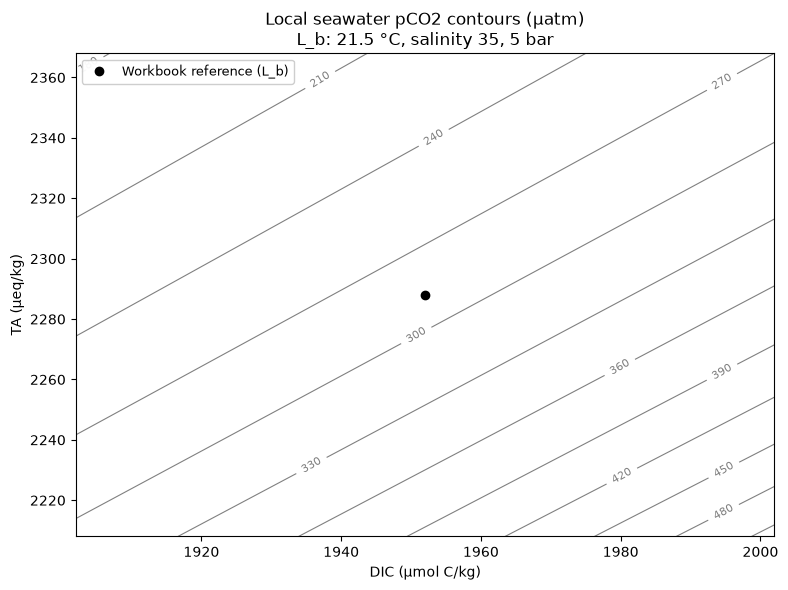

In [8]:
# Understand and run: use the contours to interpret your paired fluxes.
from teaching_plots import plot_carbonate_process_plane
plot_carbonate_process_plane(P);


<div style="background-color: #edf5ff; color: #173b61; border-left: 4px solid #3977b8; padding: 12px 16px; margin: 16px 0; border-radius: 4px;">

**Question — interpret the paired fluxes**

From the dot, remove 20 µmol C/kg through POC export and separately through CaCO3 formation. Use your paired equations to draw the two DIC–TA vectors and predict the pCO2 changes from the contours. Why do the signs differ? Reverse the carbonate vector for dissolution. Reuse these vectors in 03.4; no additional flux-effects paragraph is needed.

</div>

<!-- BEGIN SOLUTION -->
<div style="background-color: #f3eefb; color: #38224f; border-left: 4px solid #7952a8; padding: 12px 16px; margin: 16px 0; border-radius: 4px;">

**Instructor answer**

Per mole C removed from the same parcel, model POC gives $(\Delta DIC,\Delta TA)=(-1,0)$ and lowers pCO2. CaCO3 formation gives $(-1,-2)$ and raises pCO2 near this reference: reduced TA leaves more of the remaining DIC as aqueous CO2. Dissolution reverses this to $(+1,+2)$ and lowers pCO2. TA changes are equivalents per mole C. These local vectors do not imply equal concentration changes between unequal box water masses.

</div>
<!-- END SOLUTION -->

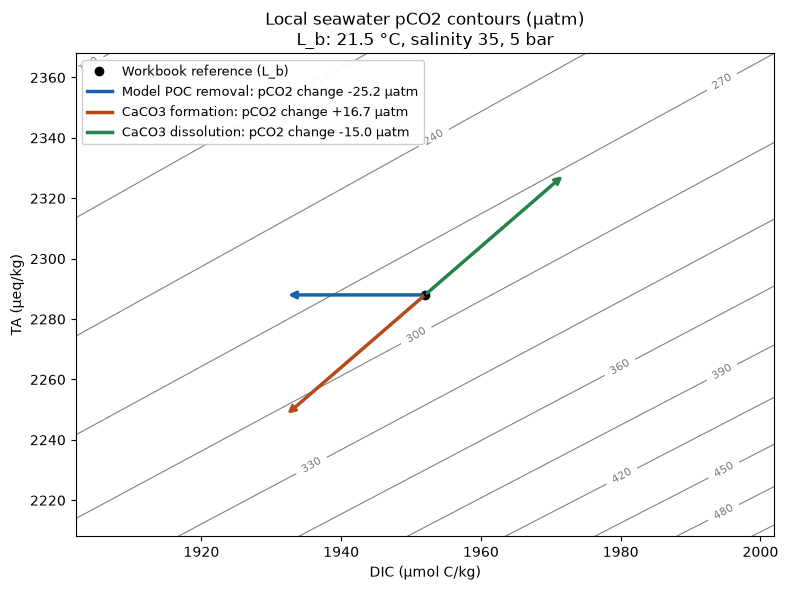

In [9]:
# Supplied implementation — instructor process arrows
plot_carbonate_process_plane(P, show_processes=True);


### A4. Reconcile your drawing with Excel

Compare the water and gas connection rows below with your arrows. Identify water routes by **source + sink + flux_id**: all three circulation rows use `thc`, so that ID alone is not unique. Check boundary-node names and correct your diagram before construction. `Fb` declares a boundary node; it does not add a separate burial drain.

The loader validates names, units and water balance, then creates parameter records. You will create the reservoirs and connections in B1–B4.

<details>
<summary>Optional reference: workbook-to-code links</summary>

| Diagram content | Input owner / stable key | Code role |
| --- | --- | --- |
| Geometry and states | OceanReservoirs / Box ID; Atmosphere | Reservoir specification |
| Water arrows | TransportConnections / source, sink, flux_id | Native bulk connections |
| Gas exchange | GasExchangeConnections / Atmosphere, Surface | Individual gas connections |
| POC and PIC | ProcessParameters / poc_export, rain_ratio | PIC derived from POC × ratio |
| Weathering | ProcessParameters / weathering_dic; BoundaryNodes / Fw | TA derived as twice weathering DIC |
| Dissolution / burial | Calculated responses, no prescribed flux row | Supplied carbonate module |

The [flux worksheets](../../ref/boudreau_diagrams.md) are teaching documentation, not live model inputs. POC/PIC/weathering topology and sediment coupling are supplied Python patterns. Changing baseline geometry, chemistry or rates requires a new compatible stationary state.

</details>


In [11]:
# Understand and run: compare these rows with the diagram you reconstructed.
display(pd.DataFrame(input_tables['TransportConnections']).sort_values('Order'))
display(pd.DataFrame(input_tables['GasExchangeConnections']).sort_values('Order'))
display(pd.DataFrame(input_tables['BoundaryNodes']).set_index('Box ID'))
# Optional lookup summarizes the same routes by unique connection ID.
from IPython.display import HTML
display(HTML(
    '<details><summary>Optional reference: connection cross-reference</summary>'
    + pd.DataFrame(workbook_connections(WORKBOOK)).set_index('ID').to_html()
    + '</details>'
))

,Order,source,sink,flux_id,Parameter,Species
0,1,H_b,D_b,mix_down,mixing,"DIC, TA"
1,2,D_b,H_b,mix_up,mixing,"DIC, TA"
2,3,L_b,H_b,thc,thc,"DIC, TA"
3,4,H_b,D_b,thc,thc,"DIC, TA"
4,5,D_b,L_b,thc,thc,"DIC, TA"


,Order,Atmosphere,Surface,Species,Parameter
0,1,CO2_At,H_b,CO2,piston_velocity
1,2,CO2_At,L_b,CO2,piston_velocity


,Type,Species,Role
Box ID,,,
Fw,Source,"DIC, TA",External weathering supply
Fb,Sink,"DIC, TA",Permanent burial boundary


,Source,Sink,Species,Parameter
ID,,,,
H_b_to_D_b@mix_down,H_b,D_b,"DIC, TA",mixing
D_b_to_H_b@mix_up,D_b,H_b,"DIC, TA",mixing
L_b_to_H_b@thc,L_b,H_b,"DIC, TA",thc
H_b_to_D_b@thc,H_b,D_b,"DIC, TA",thc
D_b_to_L_b@thc,D_b,L_b,"DIC, TA",thc
CO2_At_to_H_b@gas,CO2_At,H_b,CO2,piston_velocity
CO2_At_to_L_b@gas,CO2_At,L_b,CO2,piston_velocity


## B1. Exercise 03.2: map reservoirs

`Model` defines the clock, units and chemistry options; it is not a physical box or the system boundary. Run its supplied construction, then map the ocean records. Geometry remains explicit and ESBMTK calculates density from each box's T/S/P.

<div style="background-color: #edf5ff; color: #173b61; border-left: 4px solid #3977b8; padding: 12px 16px; margin: 16px 0; border-radius: 4px;">

**Question — map reservoir fields**

Complete `concentrations` and `geometry` using the `box` record. Use species keys `M.DIC`, `M.TA` and geometry keys `area`, `volume`. The loop and T/S/P mapping are supplied.
Trace one initial concentration from Excel to its state. Explain how volume and density convert ocn concentration to inventory, and why atm mole fraction needs a different conversion.

</div>

**Local syntax:** `box['dic']` retrieves a record field; `M.DIC` is the registered species, while `M.H_b.DIC` is its state in a particular reservoir. Dictionary keys are case-sensitive. The partial example below supplies the unchanged environmental fields.

In [12]:
# Supplied implementation: run this support code as provided.
# Supplied model clock and units.

M = Model(
    stop='20 yr',
    max_timestep='1 yr',
    element=['Carbon', 'Boron', 'Hydrogen', 'misc_variables'],
    mass_unit='mol',
    concentration_unit='mol/kg',
    opt_k_carbonic=P['opt_k_carbonic'],
    opt_pH_scale=P['opt_pH_scale'],
)

assert M.stop == Q_('20 yr').to(M.t_unit).magnitude
assert M.DIC.name == 'DIC' and M.TA.name == 'TA'


ESBMTK 0.14.3.1.post0  
 Copyright (C) 2020 - 2026  Ulrich G.Wortmann
This program comes with ABSOLUTELY NO WARRANTY
This is free software, and you are welcome to redistribute it
under certain conditions; See the LICENSE file for details.

If you use ESBMTK for your research, please cite:

Wortmann et al. 2025, https://doi.org/10.5194/gmd-18-1155-2025



In [13]:
# Understand and run: partial record-to-constructor example.
high = P['boxes']['H_b']
high_specification = {'T': high['temperature'], 'P': high['pressure'], 'S': high['salinity']}
high_specification

{'T': 2.0, 'P': 17.6, 'S': 35.0}

In [14]:
# Choose and explain: complete marked choices; surrounding machinery is supplied.
def ocean_specification(box):
    # Exercise 03.2: complete the two mappings, using your diagram and the field hints.
    # BEGIN SOLUTION
    concentrations = {M.DIC: box['dic'], M.TA: box['ta']}
    geometry = {'area': box['area'], 'volume': box['volume']}
    # END SOLUTION
    return {'c': concentrations, 'g': geometry,
            'T': box['temperature'], 'P': box['pressure'], 'S': box['salinity']}

# Supplied repetition and boundary nodes.
box_parameters = {name: ocean_specification(box) for name, box in P['boxes'].items()}
for node in P['boundary_nodes']:
    box_parameters[node['name']] = {
        'ty': node['type'], 'sp': [getattr(M, species) for species in node['species']],
    }
species_list = initialize_reservoirs(M, box_parameters)
assert {M.L_b.name, M.H_b.name, M.D_b.name} == {'L_b', 'H_b', 'D_b'}
assert set(species_list) == {M.DIC, M.TA}
for box in (M.L_b, M.H_b, M.D_b):
    assert hasattr(box, 'DIC') and hasattr(box, 'TA')

In [15]:
# Understand and run: trace this supplied step and interpret its evidence.
display(pd.DataFrame(reservoir_inventory_rows(M)).set_index('Box'))

,Density (kg/m3),Water mass (kg),Initial carbon (mol),Initial TA (mol eq)
Box,,,,
H_b,1028.798771,1.810686e+19,3.898407e+16,4.246058e+16
L_b,1024.575722,2.920041e+19,5.699920e+16,6.681053e+16
D_b,1038.983451,1.340289e+21,3.070601e+18,3.215352e+18


<!-- BEGIN SOLUTION -->
<div style="background-color: #f3eefb; color: #38224f; border-left: 4px solid #7952a8; padding: 12px 16px; margin: 16px 0; border-radius: 4px;">

**Instructor answer**

For a water mass $m=\rho V$, carbon inventory is $m\,DIC$ and TA inventory is $m\,TA$. Convert µmol/kg to mol/kg first. Atmospheric carbon is $N_{atm}x_{CO2}$ with dry-air mole fraction x; ppm must be multiplied by $10^{-6}$. `box['dic']` supplies an initial concentration, not a fixed target imposed during integration.

</div>
<!-- END SOLUTION -->

## B2. Exercise 03.3: map water arrows and their law

For water volume transport $Q_{ij}$ [m³/yr], the physical tracer flux is
$$J_{ij}^{X}(t)=\rho_iQ_{ij}X_i(t),\qquad X=\mathrm{DIC\ or\ TA}.$$
The flux removes material at the source and adds the same amount at the destination.

**Benchmark unit convention:** 02 explicitly uses $Q\rho$. The historical benchmark instead passes volume scales through a native conversion to litres/yr while the states use mol/kg. We retain that nominal numerical conversion for reproduction; it is not a general dimensional recipe for new models. Inventories still use ESBMTK densities. A physical correction requires a separately tested baseline and fresh restart.

As in 02, `Source_to_Sink@id` names a route. `ty` (or individual `ctype`) chooses the law; `sp` chooses species.

| Law choice | Meaning | Supplied coefficient |
| --- | --- | --- |
| `scale_with_concentration` | coefficient × source concentration | `sc` |
| `Fixed` | prescribed amount/time; alias of `regular` | `ra` |
| `gasexchange` | invasion minus outgassing | gas-transfer settings |

<div style="background-color: #edf5ff; color: #173b61; border-left: 4px solid #3977b8; padding: 12px 16px; margin: 16px 0; border-radius: 4px;">

**Question — implement your water arrows**

Complete endpoints, transported species and `transport_type` from your reconciled specification. For the H_b-to-D_b mixing arrow, identify which concentration appears in its law. Would substituting destination concentration necessarily fail a whole-system inventory test?

</div>

In [16]:
# Choose and explain: complete marked choices; surrounding machinery is supplied.
connection_parameters = {}
for row in P['transport_connections']:
    # Exercise 03.3: map each row's source/sink and choose the carried species.
    # BEGIN SOLUTION
    source_name = row['source']
    sink_name = row['sink']
    transported_species = [M.DIC, M.TA]
    transport_type = 'scale_with_concentration'
    # END SOLUTION
    name = f"{source_name}_to_{sink_name}@{row['id']}"
    connection_parameters[name] = {
        'ty': transport_type, 'sc': P[row['parameter']],
        'sp': transported_species,
    }
create_bulk_connections(connection_parameters, M)
assert len(M.loc) == 2 * len(P['transport_connections'])
for row in P['transport_connections']:
    connections = [conn for conn in M.loc if conn.id == row['id']
                   and conn.source.parent.name == row['source']
                   and conn.sink.parent.name == row['sink']]
    assert len(connections) == 2

<!-- BEGIN SOLUTION -->
<div style="background-color: #f3eefb; color: #38224f; border-left: 4px solid #7952a8; padding: 12px 16px; margin: 16px 0; border-radius: 4px;">

**Instructor answer**

The H_b-to-D_b flux uses H_b's current concentration. Using D_b's concentration would implement a different process, but equal source loss and destination gain could still conserve total inventory. Graph and equation checks therefore complement conservation.

</div>
<!-- END SOLUTION -->

## B3. Exercise 03.4: map biological export

Use the POC and PIC arrows from your diagram. The PIC connections remove material from L_b without directly adding it to D_b: `bp='sink'` bypasses the named destination. The supplied sediment module returns only the dissolved fraction to D_b.

<div style="background-color: #edf5ff; color: #173b61; border-left: 4px solid #3977b8; padding: 12px 16px; margin: 16px 0; border-radius: 4px;">

**Question — choose pump species, laws and linked rates**

Assign POC source/sink/species, select `export_type` from the law choices above, and link the PIC DIC and TA rates. Compare this export assumption with 02: if $DIC_s(t)$ changes while parameters stay fixed, what happens to export in each model?

</div>

In [17]:
# Choose and explain: complete marked choices; surrounding machinery is supplied.
# Supplied benchmark flux quantities.

M.tutorial_params = P
M.OM_export_reference = Q_(P['poc_export'])
M.CaCO3_export_reference = Q_(P['pic_export'])
M.OM_export = M.OM_export_reference
M.CaCO3_export = M.CaCO3_export_reference

# Exercise 03.4: select the POC arrow and link the two PIC rates.
# BEGIN SOLUTION
poc_source, poc_sink = 'L_b', 'D_b'
poc_species = M.DIC
export_type = 'Fixed'
pic_dic_rate = M.CaCO3_export
pic_ta_rate = 2 * pic_dic_rate
# END SOLUTION
create_bulk_connections(
    {
        f"{poc_source}_to_{poc_sink}@POM": {
            'sp': poc_species, 'ty': export_type, 'ra': M.OM_export,
        },
        'L_b_to_D_b@PIC_DIC': {
            'sp': M.DIC, 'ty': export_type, 'ra': pic_dic_rate, 'bp': 'sink',
        },
        'L_b_to_D_b@PIC_TA': {
            'sp': M.TA, 'ty': export_type, 'ra': pic_ta_rate, 'bp': 'sink',
        },
    },
    M,
)

M.OM_export_flux = M.flux_summary(filter_by='POM', return_list=True)[0]
M.CaCO3_export_flux = M.flux_summary(filter_by='PIC_DIC', return_list=True)[0]
M.rain_ratio = (
    M.CaCO3_export.to('Tmol/yr').magnitude
    / M.OM_export.to('Tmol/yr').magnitude
)

poc_connections = [c for c in M.loc if c.id == 'POM']
pic_dic_connections = [c for c in M.loc if c.id == 'PIC_DIC']
pic_ta_connections = [c for c in M.loc if c.id == 'PIC_TA']
assert len(poc_connections) == len(pic_dic_connections) == len(pic_ta_connections) == 1
assert pic_ta_connections[0].rate == 2 * pic_dic_connections[0].rate
assert M.rain_ratio == P['rain_ratio']

<!-- BEGIN SOLUTION -->
<div style="background-color: #f3eefb; color: #38224f; border-left: 4px solid #7952a8; padding: 12px 16px; margin: 16px 0; border-radius: 4px;">

**Instructor answer**

Here POC and PIC export remain constant. In 02, $J_{pump}(t)=kDIC_s(t)$ changes proportionally with surface DIC despite constant k. The benchmark's fixed rain ratio links baseline PIC to POC; the computed ratio afterward is a consistency check, not an independent prediction.

</div>
<!-- END SOLUTION -->

### Supplied dissolution and chemistry wiring

`add_carbonate_system_2` implements your dissolution arrow using the actual PIC flux object, deep chemistry and the snowline. Run this supplied wiring; no manual dissolution connection is needed.

The **saturation horizon** marks calcite saturation = 1; the **compensation depth** is where the arriving carbonate rain dissolves completely. These diagnostics respond to current chemistry. The snowline can lag because old sediment takes time to dissolve; this can make dissolution exceed current rain and net burial negative.

The benchmark coefficient `alpha` was tuned in the ESBMTK reproduction; agreement with its reference is not independent evidence for that coefficient.

In [18]:
# Supplied implementation: run this support code as provided.
# Supplied chemistry and sediment coupling.

add_carbonate_system_1([M.L_b, M.H_b])
add_carbonate_system_2(
    r_sb=[M.L_b],
    r_db=[M.D_b],
    carbonate_export_fluxes=[M.CaCO3_export_flux],
    z0=P['z0'],
    alpha=P['alpha'],
)

assert hasattr(M.L_b, 'CO2aq') and hasattr(M.H_b, 'CO2aq')
assert M.D_b.cs2.function_input_data[0] is M.CaCO3_export_flux

## B4. Exercise 03.5: connect the atmosphere

Map your A3 gas law to one connection per surface box. Each connection evaluates invasion minus outgassing, with equal-and-opposite atm and ocn transfers. Its endpoints define the positive direction; the net flux can reverse. Native code handles the conversions from dry-air mole fraction and mol/kg states.

Chemistry, gas exchange and circulation together produce solubility-related storage; no extra solubility-pump arrow is needed.

<div style="background-color: #edf5ff; color: #173b61; border-left: 4px solid #3977b8; padding: 12px 16px; margin: 16px 0; border-radius: 4px;">

**Question — map gas exchange**

Assign `gas_source`, `gas_sink` and `gas_species` inside the supplied loop. `getattr(M, row['atmosphere'])` retrieves the named atmospheric object; `surface_box.DIC` selects a state within a surface box. Why does gas exchange update DIC although its law uses aqueous CO2?

</div>

In [19]:
# Choose and explain: complete marked choices; surrounding machinery is supplied.

# Supplied atmosphere and loop; complete the scientifically meaningful endpoints.

GasReservoir(
    name='CO2_At', species=M.CO2, species_ppm=P['pco2'],
    reservoir_mass=P['atmosphere_moles'],
)

for row in P['gas_exchange_connections']:
    surface_box = getattr(M, row['surface'])
    # Exercise 03.5: identify atmosphere, surface carbon state and gas species.
    # BEGIN SOLUTION
    gas_source = getattr(M, row['atmosphere'])
    gas_sink = surface_box.DIC
    gas_species = getattr(M, row['species'])
    # END SOLUTION
    Species2Species(
        source=gas_source,
        sink=gas_sink,
        species=gas_species,
        piston_velocity=P[row['parameter']],
        ctype='gasexchange',
        id=surface_box.name,
    )

gas_connections = [c for c in M.loc if c.ctype == 'gasexchange']
assert len(gas_connections) == 2
assert {c.sink for c in gas_connections} == {M.L_b.DIC, M.H_b.DIC}

<!-- BEGIN SOLUTION -->
<div style="background-color: #f3eefb; color: #38224f; border-left: 4px solid #7952a8; padding: 12px 16px; margin: 16px 0; border-radius: 4px;">

**Instructor answer**

Aqueous CO2 is a diagnostic fraction of DIC. Transfer of CO2 therefore changes DIC, after which carbonate chemistry repartitions the dissolved carbon. Treating CO2aq as an additional carbon stock would count carbon twice.

</div>
<!-- END SOLUTION -->

### Supplied weathering connection

The workbook supplies `weathering_dic`; the loader sets the TA input to twice that rate. Run the supplied connection.


In [20]:
# Understand and run: trace this supplied step and interpret its evidence.
# Supplied external weathering arrow.

ConnectionProperties(
    source=M.Fw,
    sink=M.L_b,
    rate={M.DIC: P['weathering_dic'], M.TA: P['weathering_ta']},
    species=[M.DIC, M.TA],
    ctype='fixed',
    id='weathering',
)

weathering = [c for c in M.loc if c.id == 'weathering']
assert len(weathering) == 2
# Supplied metadata for the same boundary audit used in 04.
M.weathering_strength = 1.0

## C1. Check the graph before integrating

The supplied structural check matches endpoints, species, laws and process rates with the specification. Inspect this single summary and trace a water arrow, POC, linked PIC pair and gas connection to your diagram. A passing inventory check alone cannot establish that these are the intended equations.

In [22]:
# Understand and run: inspect one complete native graph summary.
connection_table = pd.DataFrame(audit_benchmark_graph(M))
display(connection_table)

,ID,Source,Sink,Law
0,H_b,CO2_At,H_b.DIC,gasexchange
1,L_b,CO2_At,L_b.DIC,gasexchange
2,PIC_DIC,L_b.DIC,D_b.DIC,regular
3,PIC_TA,L_b.TA,D_b.TA,regular
4,POM,L_b.DIC,D_b.DIC,regular
5,mix_down,H_b.DIC,D_b.DIC,scale_with_concentration
6,mix_down,H_b.TA,D_b.TA,scale_with_concentration
7,mix_up,D_b.DIC,H_b.DIC,scale_with_concentration
8,mix_up,D_b.TA,H_b.TA,scale_with_concentration
9,thc,D_b.DIC,L_b.DIC,scale_with_concentration


## C2. Complete the boundary budget

Continue **inputs minus outputs** from 01/02. Define
$$C_{atm+ocn}=N_{atm}x_{CO2}+\sum_i m_iDIC_i,\qquad
A_{ocn}=\sum_i m_iTA_i.$$
Let $W_C$ and $W_A$ denote weathering carbon and TA input, $E$ carbonate export, $D$ dissolution and $B_{net}$ signed net burial. Carbon fluxes use mol C/yr and TA fluxes equivalents/yr. Positive net burial removes material from active atm–ocn inventories.

<div style="background-color: #edf5ff; color: #173b61; border-left: 4px solid #3977b8; padding: 12px 16px; margin: 16px 0; border-radius: 4px;">

**Question — sum the inventories**

Which water, gas and organic transfers cancel? Complete $B_{net}=$ …, $dC_{atm+ocn}/dt=$ … and $dA_{ocn}/dt=$ … for this unforced model. Use your linked carbonate effects and $W_A=2W_C$. Explain why adding a separate burial sink after accounting for PIC export and dissolution would be wrong.

</div>

<!-- BEGIN SOLUTION -->
<div style="background-color: #f3eefb; color: #38224f; border-left: 4px solid #7952a8; padding: 12px 16px; margin: 16px 0; border-radius: 4px;">

**Instructor answer**

Internal water, gas and POC transfers cancel. Carbonate export removes E and dissolution returns D, so
$$B_{net}(t)=E(t)-D(t),\qquad
\frac{dC_{atm+ocn}}{dt}=W_C-B_{net}(t),\qquad
\frac{dA_{ocn}}{dt}=W_A-2B_{net}(t).$$
Counting both export-minus-dissolution and another burial sink counts the same loss twice. If D > E, negative net burial returns old sediment material. Speciation itself creates neither carbon nor TA.

</div>
<!-- END SOLUTION -->

## C3. Load the reference state and check the short restart

The archived state avoids the million-year spin-up in class. It supplies state, not connections: your graph determines subsequent tendencies.

Run 20 unforced years. The supplied check allows at most **0.01 µmol/kg DIC, 0.01 µeq/kg TA, 0.01 ppm atm CO2 and 0.01 m snowline movement**, measured at every saved time relative to the first. These are absolute teaching tolerances over this short run, not a relaxation timescale or proof of long-term stability.

The budget audit separately checks that carbon and TA inventory changes match the integrated weathering and net-burial fluxes from C2.

<details>
<summary>Technical note: numerical budget tolerance</summary>

The audit's relative tolerance (2 × 10⁻⁵ of the evolving stock, plus a small absolute allowance) includes numerical integration of diagnostic fluxes. It evaluates net burial with the solver's own law; plotting diagnostics use a slightly different carbonate evaluation.

</details>


In [23]:
# Understand and run: state loading, integration and all audits are supplied.
M.read_state(directory=str(STATE))
run_model(M)
postprocess_carbonate_horizons(M)
budget_report = audit_complete_model(M)
drift_report = pd.DataFrame(audit_restart_drift(M)).set_index('State')
assert (M.D_b.zsat.c <= M.D_b.zcc.c).all()
display(drift_report)
print('Graph and PIC coupling checked; carbon/TA budgets close; short restart drift is within the stated limits.')
print({key: value for key, value in budget_report.items() if 'error' in key})

status=0
message=The solver successfully reached the end of the integration interval.


 Execution took 0.05 CPU seconds, wall time = 0.04 seconds



,Maximum drift,Tolerance,Unit
State,,,
atm CO2,0.000006,0.01,ppm
L_b DIC,0.000042,0.01,umol/kg
L_b TA,0.000061,0.01,ueq/kg
H_b DIC,0.000068,0.01,umol/kg
H_b TA,0.000092,0.01,ueq/kg
D_b DIC,0.000126,0.01,umol/kg
D_b TA,0.000251,0.01,ueq/kg
sediment snowline,0.000171,0.01,m


Graph and PIC coupling checked; carbon/TA budgets close; short restart drift is within the stated limits.
{'max carbon error / initial stock': 5.599486194994163e-10, 'max TA error / initial stock': 1.0824442604743633e-09}


<div style="background-color: #edf5ff; color: #173b61; border-left: 4px solid #3977b8; padding: 12px 16px; margin: 16px 0; border-radius: 4px;">

**Question — explain the evidence**

Name one error that the graph check could detect despite passing conservation, and distinguish the short restart check from independent scientific validation. In your results, identify one state, one chemistry diagnostic and one flux. Use this explanation rather than another final report.

</div>

<!-- BEGIN SOLUTION -->
<div style="background-color: #f3eefb; color: #38224f; border-left: 4px solid #7952a8; padding: 12px 16px; margin: 16px 0; border-radius: 4px;">

**Instructor answer**

A conservative but misdirected internal arrow may pass a global budget; the graph comparison can detect it. Small restart drift supports local consistency between the reconstructed equations and archived state. It does not prove long-term stability or observational validity. DIC is a state, pH a chemistry diagnostic, and dissolution a calculated flux. The sediment snowline is another evolving state, not a carbonate-ion diagnostic.

</div>
<!-- END SOLUTION -->

In [24]:
from model import initialize_model

reference = initialize_model(P, stop='20 yr', max_timestep='1 yr')
reference.read_state(directory=str(STATE))
run_model(reference)
postprocess_carbonate_horizons(reference)

for student_value, reference_value in (
    (M.CO2_At.c[-1], reference.CO2_At.c[-1]),
    (M.L_b.DIC.c[-1], reference.L_b.DIC.c[-1]),
    (M.L_b.TA.c[-1], reference.L_b.TA.c[-1]),
    (M.D_b.DIC.c[-1], reference.D_b.DIC.c[-1]),
    (M.D_b.zcc.c[-1], reference.D_b.zcc.c[-1]),
):
    assert abs(student_value - reference_value) <= max(abs(reference_value), 1.0) * 1e-10

print('Construction verified: the student-built and reusable models agree.')


ESBMTK 0.14.3.1.post0  
 Copyright (C) 2020 - 2026  Ulrich G.Wortmann
This program comes with ABSOLUTELY NO WARRANTY
This is free software, and you are welcome to redistribute it
under certain conditions; See the LICENSE file for details.

If you use ESBMTK for your research, please cite:

Wortmann et al. 2025, https://doi.org/10.5194/gmd-18-1155-2025



INFO:root:bypassing M.Conn_L_b_to_D_b_DIC_PIC_DIC._FPIC_DIC in M.D_b.DIC
INFO:root:bypassing M.Conn_L_b_to_D_b_TA_PIC_TA._FPIC_TA in M.D_b.TA
INFO:root:creating M_L_b_cs_generic_function
INFO:root:creating M_H_b_cs_generic_function
INFO:root:creating M_D_b_cs2_generic_function
INFO:root:creating M_H_b_DIC_gas_exchangeH_b_generic_function
INFO:root:creating M_L_b_DIC_gas_exchangeL_b_generic_function
INFO:root:================================================================================
INFO:root:Intergration started at 2026-09-24 13:01:38.040680
INFO:root:r = M.H_b.DIC, r.c[0] = 2.15e-03, rtol = 2.15e-08
INFO:root:r = M.H_b.TA, r.c[0] = 2.35e-03, rtol = 2.35e-08
INFO:root:r = M.L_b.DIC, r.c[0] = 1.94e-03, rtol = 1.94e-08
INFO:root:r = M.L_b.TA, r.c[0] = 2.28e-03, rtol = 2.28e-08
INFO:root:r = M.D_b.DIC, r.c[0] = 2.30e-03, rtol = 2.30e-08
INFO:root:r = M.D_b.TA, r.c[0] = 2.40e-03, rtol = 2.40e-08
INFO:root:r = M.L_b.Hplus, r.c[0] = 5.40e-09, rtol = 5.40e-14
INFO:root:r = M.L_b.CO2aq, 

status=0
message=The solver successfully reached the end of the integration interval.


 Execution took 0.03 CPU seconds, wall time = 0.04 seconds

Construction verified: the student-built and reusable models agree.


**You have completed 03.** Keep the reconstructed diagram, flux table, four mappings and budget explanation. Reuse the diagram in 04. Detailed sediments and process attribution remain optional.